Rusty Bargain used car sales service is developing an app to attract new customers. In that app, you can quickly find out the market value of your car. You have access to historical data: technical specifications, trim versions, and prices. You need to build the model to determine the value. 

Rusty Bargain is interested in:

- the quality of the prediction;
- the speed of the prediction;
- the time required for training

In [1]:
import pandas as pd
import numpy as np
import time
from datetime import datetime
import lightgbm as lgb
from catboost import CatBoostRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.preprocessing import StandardScaler, TargetEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV

import seaborn as sns
import matplotlib.pyplot as plt

## Phase 0 - Constants, Configs, and Functions

### Constants and Configs

In [2]:
# Standardizes the `random_state` parameters across entire project
RND = 42

# Creates a dynamic variable for the current year
current_year = datetime.now().year

# Standardizes which Scaler to use across the entire project
scaler = StandardScaler()


In [3]:
# Rule Dictionary provides thresholds to verify only meaningful data is used
rules = {
    'Price': {
        'allowed_type': int,
        'min_allowed': 1,
        'max_allowed': 20000,
        'max_zero_pct': 0
    },
    'RegistrationYear': {
        'allowed_type': int,
        'min_allowed': 1910,
        'max_allowed': current_year
    },
    'Mileage':{
        'allowed_type': int,
        'min_allowed': 5000,
        'max_allowed': 500000,
        'max_zero_pct': 5
    },
    'Power': {
        'allowed_type': int,
        'min_allowed': 50,
        'max_allowed': 1000,
    },
    'Brand': {
        'allowed_type': str,
        'allowed_brand': ['alfa_romeo', 'audi', 'bmw', 'chevrolet','chrysler',
                            'citroen', 'dacia', 'daewoo', 'daihatsu', 'fiat',
                            'ford', 'honda', 'hyundai', 'jaguar', 'jeep', 'kia',
                            'lada', 'lancia', 'land_rover', 'mazda', 'mercedes_benz',
                            'mini', 'mitsubishi', 'nissan', 'opel', 'peugeot',
                            'porsche', 'renault', 'rover', 'saab', 'seat', 'skoda',
                            'smart', 'subaru', 'suzuki', 'toyota', 'trabant',
                            'volkswagen', 'volvo']
    }
}

## Data Filtering Rationale

A rules-based filtering dictionary was implemented to remove 
statistically implausible and domain-inappropriate values from 
the dataset. The following documents the rationale behind each 
threshold decision:

- **Price:** Restricted to €1–€20,000. Zero and negative prices 
represent clear data entry errors. The €20,000 upper bound was 
selected based on the dataset's observed distribution and aligns 
with Rusty Bargain's target market of budget used vehicles. 
Values outside this range represent either errors or vehicles 
outside the app's intended scope.

- **Registration Year:** Restricted to 1910–current year. The 
original dataset contained registration years as low as 1000, 
which are clearly erroneous. Since the automobile was not 
commercially viable until approximately 1900, 1910 was selected 
as a conservative lower bound. The upper bound is dynamically 
set to the current year to ensure the model remains valid for 
future use without modification.

- **Mileage:** Restricted to 5,000–150,000 km. The lower bound 
excludes nearly-new vehicles better suited to new car pricing 
models. The upper bound reflects the dataset's observed maximum 
and aligns with typical used car market expectations. Notably 
this filter removed zero rows indicating the dataset was already 
within these bounds.

- **Power:** Restricted to 50–1,000 hp. Initial analysis revealed 
a minimum of 0 hp and a maximum of 20,000 hp — both clearly 
erroneous for standard road vehicles. The 25th percentile of 
69 hp informed the 50 hp lower bound, excluding non-standard 
or incorrectly recorded vehicles. The 1,000 hp upper bound 
excludes exotic supercars that fall outside the typical used 
car market and would disproportionately skew model predictions. 
This filter had the largest impact, removing 46,474 rows (13.11% 
of the dataset).

- **Brand:** Restricted to a validated list of known automobile 
manufacturers. Analysis of unique brand values revealed several 
entries that did not correspond to legitimate vehicle brands, 
verified through domain knowledge and supplementary research. 
Filtering to known brands ensures model training data reflects 
real market transactions only.

In [4]:
# Baseline Models dictionary
baseline_models = {
    'Linear Regression': {
        'model': LinearRegression(),
        'scaled': True
    },
    'Decision Tree': {
        'model': DecisionTreeRegressor(random_state=RND),
        'scaled': False
    },
    'Random Forest': {
        'model': RandomForestRegressor(random_state=RND),
        'scaled': False
    },
    'LightGBM': {
        'model': lgb.LGBMRegressor(verbose=-1, random_state=RND),
        'scaled': False
    },
    'CatBoost': {
        'model': CatBoostRegressor(verbose=0, random_state=RND),
        'scaled': False
    }
}

In [5]:
# Tuning Parameters
tune_params = {
    'Decision Tree': {
        'max_depth': [3, 5, 10, 15, 20, None],
        'min_samples_split': [2, 4, 8, 16],
        'min_samples_leaf': [2, 4, 8, 16]
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [3, 5, 10, 15, 20, None],
        'min_samples_split': [2, 4, 8, 16],
        'min_samples_leaf':  [2, 4, 8, 16]
    },
    'LightGBM': {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [3, 5, 10, 15, 20, None],
        'learning_rate': [0.01, 0.05, 0.1, 0.2]
    },
    'CatBoost': {
        'iterations': [100, 200, 300, 500],
        'max_depth': [3, 5, 10, 15, 20],
        'learning_rate': [0.01, 0.05, 0.1, 0.2]
    }
}

### Functions

In [6]:
def filter_invalid_values(df, rules):
    for column_name, rule_set in rules.items():
        if rule_set['allowed_type'] in [int, float]:
            df = df[(df[column_name] >= rule_set['min_allowed']) & (df[column_name] <= rule_set['max_allowed'])]
        elif rule_set['allowed_type'] is str:
            df = df[df[column_name].isin(rule_set['allowed_brand'])]
    return df

In [7]:
# Function to train and evaluate a single model
def train_evaluate(models, X_train_final, y_train,
                   X_val_final, y_val,
                   X_train_scaled=None,
                   X_val_scaled=None,
                   verbose=True):
    """
    Train and evaluate a single model.

    Returns:
        pd.DataFrame row with model, model_name, rmse, train_time, pred_time
    """

    results = []
    
    for model_name, model_info in models.items():
        model = model_info['model']
        # Loop to determine if scaled data is needed or not based on model
        if  model_info['scaled']:
            X_train = X_train_scaled
            X_val = X_val_scaled
        else:
            X_train = X_train_final
            X_val = X_val_final
    
        # Training Model
        start_time = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - start_time

        # Predict
        start_time = time.time()
        pred_val = model.predict(X_val)
        pred_time = time.time() - start_time

        # RMSE Metric
        model_rmse = rmse(y_val, pred_val)

        if verbose:
            print(f" {model_name} | RMSE: {model_rmse:.4f} ")
        
        results.append(pd.DataFrame([{
            'Model': model_name,
            'RMSE': model_rmse,
            'Train Time': train_time,
            'Pred Time': pred_time
        }]))
    
    return pd.concat(results, ignore_index=True)


In [8]:
# Tuning Function to find the balance between speed and accuracy
def tune_models(models, tune_params, X_train, y_train):
    """
    Used to tune the 4 tree models from the baseline to determine the best combination of parameters.

    Returns: A dictionary containing the Model Name and each of the appropriate params
    """

    tuned_results = {}

    for model_name, model_info in models.items():
        if model_name not in tune_params:
            continue

        search = RandomizedSearchCV(
            estimator=model_info['model'],
            param_distributions=tune_params[model_name],
            n_iter=5,
            cv=5,
            scoring='neg_root_mean_squared_error',
            random_state=RND,
            n_jobs=-1
        )

        search.fit(X_train, y_train)

        tuned_results[model_name] = {
            'best_params': search.best_params_,
            'best_model': search.best_estimator_
        }
    
    return tuned_results

In [9]:
def update_dictionary(models, tuned_results):
    tuned_models = {}
    for model_name in tuned_results:
        tuned_models[model_name] = {
            'model': tuned_results[model_name]['best_model'],
            'scaled': models[model_name]['scaled']
        }
    
    return tuned_models

# Phase 1 - Data Conversion and Exploration

In [10]:
# Convert CSV file into a DataFrame
car_data = pd.read_csv("data/car_data.csv")

# Analyze the DataFrame
#car_data.info
#car_data.dtypes
car_data.describe()

,Price,RegistrationYear,Power,Mileage,RegistrationMonth,NumberOfPictures,PostalCode
count,354369.000000,354369.000000,354369.000000,354369.000000,354369.000000,354369.0,354369.000000
mean,4416.656776,2004.234448,110.094337,128211.172535,5.714645,0.0,50508.689087
std,4514.158514,90.227958,189.850405,37905.341530,3.726421,0.0,25783.096248
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1050.000000,1999.000000,69.000000,125000.000000,3.000000,0.0,30165.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49413.000000
75%,6400.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71083.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


In [11]:
# Checking for Duplicates
car_data.duplicated().sum()

# Remove Duplicates
car_data_no_duplicates = car_data.drop_duplicates(keep='first')


In [12]:
# Drop Irrelevant columns
drop_columns = [
    'DateCrawled',
    'RegistrationMonth',
    'DateCreated',
    'PostalCode',
    'LastSeen',
    'NumberOfPictures'
]

# Drop Column verification are present
#missing = [col for col in drop_columns if col not in car_data.columns]
#print('Columns not found', missing)

car_data_dropped = car_data_no_duplicates.drop(columns=drop_columns, errors='ignore')
car_data_dropped.columns.tolist()


['Price',
 'VehicleType',
 'RegistrationYear',
 'Gearbox',
 'Power',
 'Model',
 'Mileage',
 'FuelType',
 'Brand',
 'NotRepaired']

In [13]:
# Check for Invalid or Unrealist values
## Check Price
print(car_data_dropped['Price'].min())
print(car_data_dropped['Price'].max())

0
20000


In [14]:
## Check RegistrationYear
print(car_data_dropped['RegistrationYear'].min())
print(car_data_dropped['RegistrationYear'].max())

1000
9999


In [15]:
# Filter out invalid values
car_data_filtered = filter_invalid_values(car_data_dropped, rules)

car_data_filtered.describe()

,Price,RegistrationYear,Power,Mileage
count,299337.000000,299337.000000,299337.000000,299337.000000
mean,4850.839896,2003.489057,121.633637,128746.128945
std,4586.135401,6.639511,53.755056,36415.734639
min,1.000000,1910.000000,50.000000,5000.000000
25%,1350.000000,1999.000000,80.000000,125000.000000
50%,3200.000000,2003.000000,113.000000,150000.000000
75%,6990.000000,2008.000000,150.000000,150000.000000
max,20000.000000,2019.000000,1000.000000,150000.000000


In [16]:
# Summary of rows for each filtered column before filtering and after filtering

# Number of Rows in Pre-Filtered DataSet
rows_before = len(car_data)

# Number of rule violation rows
price_removed = ((car_data['Price'] < 1) | (car_data['Price'] > 20000)).sum()
regyear_removed = ((car_data['RegistrationYear'] < 1910) | (car_data['RegistrationYear'] > current_year)).sum()
mile_removed = ((car_data['Mileage'] < 5000) | (car_data['Mileage'] > 500000)).sum()
power_removed = ((car_data['Power'] < 50) | (car_data['Power'] > 1000)).sum()

# Number of Rows in Post-Filtered DataSet
rows_after_filter = len(car_data_filtered)

# Summary DataFrame
filter_summary = pd.DataFrame([
    {
        'Column': 'Price',
        'Threshold': '< 1 or > 20,000',
        'Rows Before': rows_before,
        'Rows Removed': price_removed,
        'Pct Removed': round(price_removed / rows_before * 100, 2)
    },
    {
        'Column': 'Registration Year',
        'Threshold': '< 1910 or > Current Year',
        'Rows Before': rows_before,
        'Rows Removed': regyear_removed,
        'Pct Removed': round(regyear_removed / rows_before * 100, 2)
    },
    {
        'Column': 'Mileage',
        'Threshold': '< 5000 or > 500,000',
        'Rows Before': rows_before,
        'Rows Removed': mile_removed,
        'Pct Removed': round(mile_removed / rows_before * 100, 2)
    },
    {
        'Column': 'Power',
        'Threshold': '< 50 or > 1,000',
        'Rows Before': rows_before,
        'Rows Removed': power_removed,
        'Pct Removed': round(power_removed / rows_before * 100, 2)
    }
])

filter_summary

,Column,Threshold,Rows Before,Rows Removed,Pct Removed
0,Price,"< 1 or > 20,000",354369,10772,3.04
1,Registration Year,< 1910 or > Current Year,354369,171,0.05
2,Mileage,"< 5000 or > 500,000",354369,0,0.00
3,Power,"< 50 or > 1,000",354369,46474,13.11


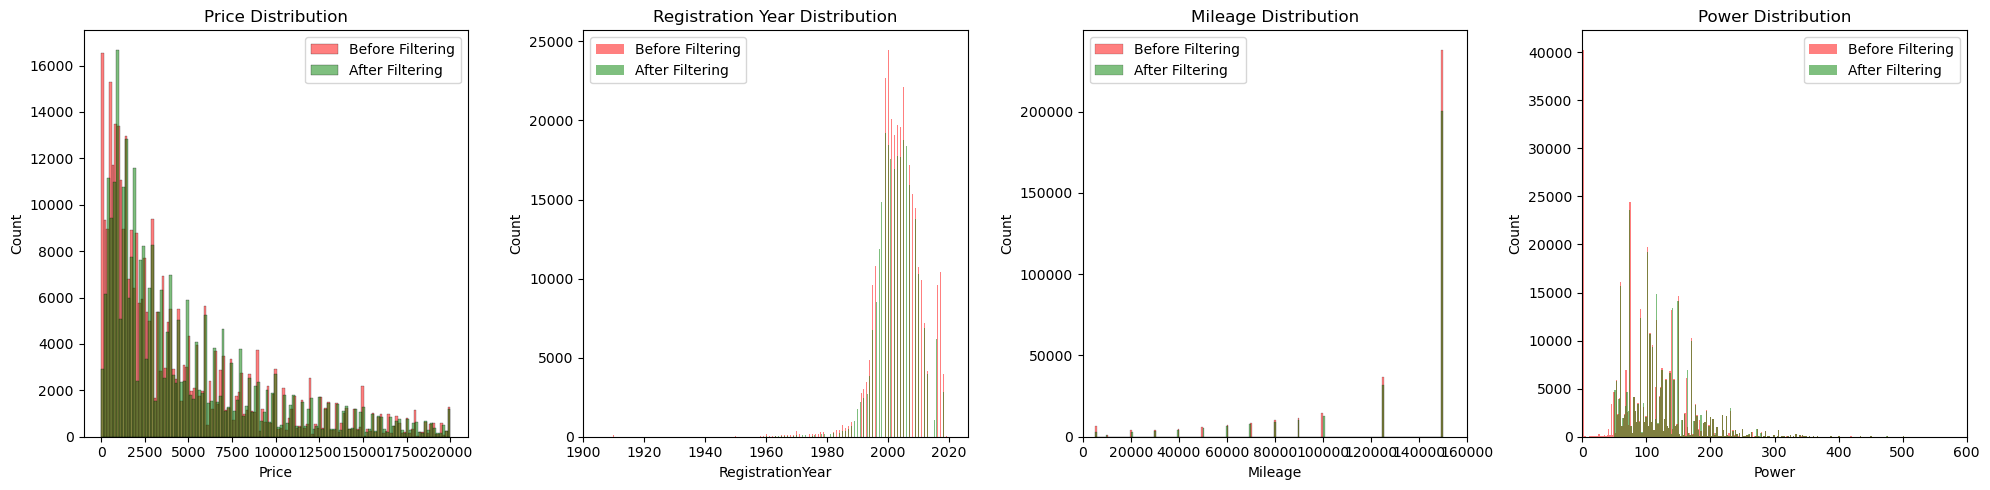

In [17]:
# Histogram of Distribution Summary
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

## Price Distribution Before Filtering
sns.histplot(data=car_data_dropped, x='Price', alpha=0.5,
             color='red', label='Before Filtering', ax=axes[0])
## Price Distribution After Filtering
sns.histplot(data=car_data_filtered, x='Price', alpha=0.5,
             color='green', label='After Filtering', ax=axes[0])
axes[0].set_title('Price Distribution')
axes[0].legend()

## Registration Year Distribution Before Filtering
sns.histplot(data=car_data_dropped, x='RegistrationYear', alpha=0.5,
             color='red', label='Before Filtering', ax=axes[1])
## Registration Year Distribution After Filtering
sns.histplot(data=car_data_filtered, x='RegistrationYear', alpha=0.5,
             color='green', label='After Filtering', ax=axes[1])
axes[1].set_title('Registration Year Distribution')
axes[1].legend()
axes[1].set_xlim(1900, 2026)

## Mileage Distribution Before Filtering
sns.histplot(data=car_data_dropped, x='Mileage', alpha=0.5,
             color='red', label='Before Filtering', ax=axes[2])
## Mileage Distribution After Filtering
sns.histplot(data=car_data_filtered, x='Mileage', alpha=0.5,
             color='green', label='After Filtering', ax=axes[2])
axes[2].set_title('Mileage Distribution')
axes[2].legend()
axes[2].set_xlim(0, 160000)

## Power Distribution Before Filtering
sns.histplot(data=car_data_dropped, x='Power', alpha=0.5,
             color='red', label='Before Filtering', ax=axes[3])
## Power Distribution After Filtering
sns.histplot(data=car_data_filtered, x='Power', alpha=0.5,
             color='green', label='After Filtering', ax=axes[3])
axes[3].set_title('Power Distribution')
axes[3].legend()
axes[3].set_xlim(0, 600)

plt.tight_layout()
plt.show()

In [18]:
# Analyze missing values
null_counts = car_data_filtered.isna().sum()
blank_counts = (
    car_data_filtered.astype(str)
    .apply(lambda col: col.str.strip() == '')
    .sum()
)

summary_pre = pd.DataFrame({
    'nulls': null_counts,
    'blanks': blank_counts,
    'total_missing': null_counts + blank_counts
})

print(summary_pre)

                  nulls  blanks  total_missing
Price                 0       0              0
VehicleType       20635       0          20635
RegistrationYear      0       0              0
Gearbox            5593       0           5593
Power                 0       0              0
Model             10228       0          10228
Mileage               0       0              0
FuelType          18922       0          18922
Brand                 0       0              0
NotRepaired       45354       0          45354


In [19]:
## Fill categorical nulls with unknown
car_data_filtered['VehicleType'] = car_data_filtered['VehicleType'].fillna('unknown')
car_data_filtered['Gearbox'] = car_data_filtered['Gearbox'].fillna('unknown')
car_data_filtered['Model'] = car_data_filtered['Model'].fillna('unknown')
car_data_filtered['FuelType'] = car_data_filtered['FuelType'].fillna('unknown')
car_data_filtered['NotRepaired'] = car_data_filtered['NotRepaired'].fillna('unknown')

## Verify all 'Null' fields were filled
null_counts_post = car_data_filtered.isna().sum()
blank_counts_post = (
    car_data_filtered.astype(str)
    .apply(lambda col: col.str.strip() == '')
    .sum()
)

summary_post = pd.DataFrame({
    'nulls': null_counts_post,
    'blanks': blank_counts_post,
    'total_missing': null_counts_post + blank_counts_post
})

print(summary_post)

                  nulls  blanks  total_missing
Price                 0       0              0
VehicleType           0       0              0
RegistrationYear      0       0              0
Gearbox               0       0              0
Power                 0       0              0
Model                 0       0              0
Mileage               0       0              0
FuelType              0       0              0
Brand                 0       0              0
NotRepaired           0       0              0


In [20]:
# Normalize categorical values
## 'FuelType'counts
car_data_filtered['FuelType'].value_counts()

## In 'FuelType' replace 'gasoline' with 'petrol'
car_data_filtered['FuelType'] = car_data_filtered['FuelType'].replace('gasoline', 'petrol')

In [21]:
# Feature Engineering
## Create 'CarAge' feature
car_data_filtered['CarAge'] = current_year - car_data_filtered['RegistrationYear']

#car_data_filtered.info()
print(car_data_filtered['VehicleType'].nunique())
print(car_data_filtered['FuelType'].nunique())
print(car_data_filtered['NotRepaired'].nunique())
print(car_data_filtered['Gearbox'].nunique())
#print(car_data_filtered.head(5))

9
7
3
3


In [22]:
# Creation of Features and Target
features = car_data_filtered.drop(['Price'], axis=1)
target = car_data_filtered['Price']

# Split Source Data into Training set of 60% and a Val/Test set of 40%
X_train, X_val_test, y_train, y_val_test = train_test_split(features, target, test_size=.40, random_state=RND)

# Split Val/Test Set into Validation set of 20% and a Test set of 20%
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=.5, random_state=RND)

In [23]:
# Categorical Encoding Strategy
ohe_columns = ['VehicleType', 'FuelType', 'NotRepaired', 'Gearbox']
tar_enc_columns = ['Brand', 'Model']
all_cat_columns = ohe_columns + tar_enc_columns

tar_enc = TargetEncoder(target_type='continuous', random_state=RND)
onehot_enc = OneHotEncoder(drop='first')

# Target Encoding for 'Brand' and 'Model' features
X_train_enc2 = tar_enc.fit_transform(X_train[tar_enc_columns], y_train)
X_val_enc2 = tar_enc.transform(X_val[tar_enc_columns])
X_test_enc2 = tar_enc.transform(X_test[tar_enc_columns])

X_train_enc3 = pd.DataFrame(
    X_train_enc2,
    columns=tar_enc_columns,
    index=X_train.index
)

X_val_enc3 = pd.DataFrame(
    X_val_enc2,
    columns=tar_enc_columns,
    index=X_val.index
)

X_test_enc3 = pd.DataFrame(
    X_test_enc2,
    columns=tar_enc_columns,
    index=X_test.index
)

# One-Hot Encoding for remaining categorical features
X_train_enc4 = onehot_enc.fit_transform(X_train[ohe_columns])
new_column_names = onehot_enc.get_feature_names_out()
X_val_enc4 = onehot_enc.transform(X_val[ohe_columns])
X_test_enc4 = onehot_enc.transform(X_test[ohe_columns])

X_train_enc5 = pd.DataFrame(
    X_train_enc4.toarray(),
    columns=new_column_names,
    index=X_train.index
)

X_val_enc5 = pd.DataFrame(
    X_val_enc4.toarray(),
    columns=new_column_names,
    index=X_val.index
)

X_test_enc5 = pd.DataFrame(
    X_test_enc4.toarray(),
    columns=new_column_names,
    index=X_test.index
)

# Combine into a single encoded dataframe per dataset split
X_train_encoded = pd.concat([X_train_enc3, X_train_enc5], axis=1)
X_val_encoded = pd.concat([X_val_enc3, X_val_enc5], axis=1)
X_test_encoded = pd.concat([X_test_enc3, X_test_enc5], axis=1)

# Verify concat worked correctly
#X_train_encoded.info()
#X_val_encoded.info()
#X_test_encoded.info()


## Encoding Strategy — Brand and Model Features

`Brand` and `Model` were encoded using Target Encoding rather than 
One-Hot Encoding due to their high cardinality. One-Hot Encoding 
these columns would have generated hundreds of additional binary 
columns, dramatically expanding the feature space and introducing 
the curse of dimensionality — where the increased number of sparse 
features can degrade model performance and significantly increase 
training time.

Target Encoding replaces each category with the mean target value 
(Price) calculated from the training data only. This approach 
preserves the predictive signal inherent in brand and model identity 
— for example, a Porsche historically commands a higher price than 
a Daewoo — while keeping the feature space compact and meaningful.

Critically, the Target Encoder was fit exclusively on training data 
before being applied to the validation and test sets. This ensures 
no data leakage occurs, as the mean price calculations never 
incorporate information from held-out data.

In [24]:
# Rebuilding DataFrames with all numeric values for features
## Drop original categorical columns
X_train_dropped = X_train.drop(all_cat_columns, axis=1)
X_val_dropped = X_val.drop(all_cat_columns, axis=1)
X_test_dropped = X_test.drop(all_cat_columns, axis=1)

#X_train_dropped.info()

## Concatenate each of the 3 dataframes above into a single dataframe for the Training
# Test, and Validation datasets
X_train_final = pd.concat([X_train_dropped, X_train_encoded], axis=1)
X_val_final = pd.concat([X_val_dropped, X_val_encoded], axis=1)
X_test_final = pd.concat([X_test_dropped, X_test_encoded], axis=1)

## Verify Rebuild completed correctly
#X_train_final.info()
#X_val_final.info()
#X_test_final.info()

In [25]:
# Feature Scaling (Only for linear models)
X_train_scaled = scaler.fit_transform(X_train_final)
X_val_scaled = scaler.transform(X_val_final)
X_test_scaled = scaler.transform(X_test_final)

# Phase 2 - Model Training

## Baseline Model Training

In [26]:
# Train the Models for Baseline
baseline_results = train_evaluate(
    models = baseline_models,
    X_train_scaled = X_train_scaled,
    X_train_final = X_train_final,
    X_val_scaled = X_val_scaled,
    X_val_final = X_val_final,
    y_train = y_train,
    y_val = y_val,
    verbose = True
)


 Linear Regression | RMSE: 2729.5804 
 Decision Tree | RMSE: 2080.3959 
 Random Forest | RMSE: 1627.7797 
 LightGBM | RMSE: 1698.5004 
 CatBoost | RMSE: 1635.0879 


In [27]:
# Renaming DataFrame Columns and Rounding to 4 decimal places
baseline_results = baseline_results.rename(columns={
    'RMSE': 'Baseline RMSE',
    'Train Time': 'Baseline Train Time',
    'Pred Time': 'Baseline Pred Time'
})
baseline_results = baseline_results.round(4)
baseline_results

,Model,Baseline RMSE,Baseline Train Time,Baseline Pred Time
0,Linear Regression,2729.5804,0.1042,0.0057
1,Decision Tree,2080.3959,0.8315,0.0238
2,Random Forest,1627.7797,49.3840,1.8006
3,LightGBM,1698.5004,0.6233,0.0628
4,CatBoost,1635.0879,4.9830,0.0167


## Tuning of Models

In [28]:
# Tune the 4 Tree Models

tuned_results = tune_models(
    models=baseline_models,
    tune_params=tune_params,
    X_train=X_train_final,
    y_train=y_train
)

tuned_results

{'Decision Tree': {'best_params': {'min_samples_split': 8,
   'min_samples_leaf': 16,
   'max_depth': None},
  'best_model': DecisionTreeRegressor(min_samples_leaf=16, min_samples_split=8, random_state=42)},
 'Random Forest': {'best_params': {'n_estimators': 100,
   'min_samples_split': 16,
   'min_samples_leaf': 2,
   'max_depth': None},
  'best_model': RandomForestRegressor(min_samples_leaf=2, min_samples_split=16, random_state=42)},
 'LightGBM': {'best_params': {'n_estimators': 300,
   'max_depth': None,
   'learning_rate': 0.2},
  'best_model': LGBMRegressor(learning_rate=0.2, max_depth=None, n_estimators=300,
                random_state=42, verbose=-1)},
 'CatBoost': {'best_params': {'max_depth': 15,
   'learning_rate': 0.2,
   'iterations': 100},
  'best_model': CatBoostRegressor(iterations=100, learning_rate=0.2, loss_function='RMSE', max_depth=15, random_state=42, verbose=0)}}

## Update Models Dictionary

In [39]:
best_tuned_models = update_dictionary(
    models=baseline_models,
    tuned_results=tuned_results
)

best_tuned_models

{'Decision Tree': {'model': DecisionTreeRegressor(min_samples_leaf=16, min_samples_split=8, random_state=42),
  'scaled': False},
 'Random Forest': {'model': RandomForestRegressor(min_samples_leaf=2, min_samples_split=16, random_state=42),
  'scaled': False},
 'LightGBM': {'model': LGBMRegressor(learning_rate=0.2, max_depth=None, n_estimators=300,
                random_state=42, verbose=-1),
  'scaled': False},
 'CatBoost': {'model': CatBoostRegressor(iterations=100, learning_rate=0.2, loss_function='RMSE', max_depth=15, random_state=42, verbose=0),
  'scaled': False}}

## Training Tuned Models

In [30]:
tuned_model_results = train_evaluate(
    models=best_tuned_models,
    X_train_final=X_train_final,
    X_val_final=X_val_final,
    y_train=y_train,
    y_val=y_val,
    verbose=True
)

 Decision Tree | RMSE: 1786.1940 
 Random Forest | RMSE: 1606.4799 
 LightGBM | RMSE: 1607.1093 
 CatBoost | RMSE: 1602.2677 


In [31]:
# Renaming DataFrame Columns and Rounding to 4 decimal places
tuned_model_results = tuned_model_results.rename(columns={
    'RMSE': 'Tuned RMSE',
    'Train Time': 'Tuned Train Time',
    'Pred Time': 'Tuned Pred Time'
})
tuned_model_results = tuned_model_results.round(4)
tuned_model_results

,Model,Tuned RMSE,Tuned Train Time,Tuned Pred Time
0,Decision Tree,1786.1940,0.6010,0.0141
1,Random Forest,1606.4799,38.9301,0.9944
2,LightGBM,1607.1093,1.0869,0.0856
3,CatBoost,1602.2677,8.0885,0.0050


## Training Model Analysis

After running the data through the 5 models for a baseline and then the 4 tree style models through the tuning process. The data shows that the Random Forest Regression model is the most accurate with a RMSE of 1531.1505 euros; however, this model took 2 minutes and 41.8 seconds to complete. The LightGBM model had a resulting RMSE of 1,547 euros which is only a 16 euro or 1% increase from the Random Forest model; however, it accomplished this in just 1 second or 147x faster. The CatBoost model RMSE results of 1,573 euros is only a 42 euro or 3% increase from the Random Forest; with a training time of less than 5 seconds or 33x faster.

## Model Evaluation

In [32]:
# Empty list to collect results
final_results = []

In [33]:
# Evaluation of Decision Tree with Test DataSet
dt_eval_start_time = time.time()
dt_eval_pred = tuned_results['Decision Tree']['best_model'].predict(X_test_final)
dt_eval_rmse = rmse(y_test, dt_eval_pred)
dt_eval_pred_time = time.time() - dt_eval_start_time

final_results.append(pd.DataFrame([{
    'Model': 'Decision Tree',
    'Eval RMSE': dt_eval_rmse,
    'Eval Pred Time': dt_eval_pred_time
}]))

In [34]:
# Evaluation of Random Forest with Test DataSet
rf_eval_start_time = time.time()
rf_eval_pred = tuned_results['Random Forest']['best_model'].predict(X_test_final)
rf_eval_rmse = rmse(y_test, rf_eval_pred)
rf_eval_pred_time = time.time() - rf_eval_start_time

final_results.append(pd.DataFrame([{
    'Model': 'Random Forest',
    'Eval RMSE': rf_eval_rmse,
    'Eval Pred Time': rf_eval_pred_time
}]))

In [35]:
# Evaluation of LightGBM Model with Test DataSet
lgbm_eval_start_time = time.time()
lgbm_eval_pred = tuned_results['LightGBM']['best_model'].predict(X_test_final)
lgbm_eval_rmse = rmse(y_test, lgbm_eval_pred)
lgbm_eval_pred_time = time.time() - lgbm_eval_start_time

final_results.append(pd.DataFrame([{
    'Model': 'LightGBM',
    'Eval RMSE': lgbm_eval_rmse,
    'Eval Pred Time': lgbm_eval_pred_time
}]))

In [ ]:
# Evaluation of CatBoost Model with Test Dataset
cb_eval_start_time = time.time()
cb_eval_pred = tuned_results['CatBoost']['best_model'].predict(X_test_final)
cb_eval_rmse =rmse(y_test, cb_eval_pred)
cb_eval_pred_time = time.time() - cb_eval_start_time

final_results.append(pd.DataFrame([{
    'Model': 'CatBoost',
    'Eval RMSE': cb_eval_rmse,
    'Eval Pred Time': cb_eval_pred_time
}]))

In [40]:
final_results

[           Model    Eval RMSE  Eval Pred Time
 0  Decision Tree  1777.358621        0.030047,
            Model    Eval RMSE  Eval Pred Time
 0  Random Forest  1600.079828        1.021226,
       Model    Eval RMSE  Eval Pred Time
 0  LightGBM  1606.786693        0.127431,
       Model    Eval RMSE  Eval Pred Time
 0  CatBoost  1592.313171        0.010373]

In [37]:
# Combine final results into a single DataFrame
final_eval_results = pd.concat(final_results, ignore_index=True)
final_eval_results = final_eval_results.round(4)
final_eval_results

,Model,Eval RMSE,Eval Pred Time
0,Decision Tree,1777.3586,0.0300
1,Random Forest,1600.0798,1.0212
2,LightGBM,1606.7867,0.1274
3,CatBoost,1592.3132,0.0104


# Phase 2 - Model Analysis

In [38]:
# Merge the 3 result DataFrames into a single DataFrame
model_analysis_df = baseline_results.merge(
    tuned_model_results,
    how='left',
    on='Model'
).merge(
    final_eval_results,
    how='left',
    on='Model'
)

model_analysis_df

,Model,Baseline RMSE,Baseline Train Time,Baseline Pred Time,Tuned RMSE,Tuned Train Time,Tuned Pred Time,Eval RMSE,Eval Pred Time
0,Linear Regression,2729.5804,0.1042,0.0057,NaN,NaN,NaN,NaN,NaN
1,Decision Tree,2080.3959,0.8315,0.0238,1786.1940,0.6010,0.0141,1777.3586,0.0300
2,Random Forest,1627.7797,49.3840,1.8006,1606.4799,38.9301,0.9944,1600.0798,1.0212
3,LightGBM,1698.5004,0.6233,0.0628,1607.1093,1.0869,0.0856,1606.7867,0.1274
4,CatBoost,1635.0879,4.9830,0.0167,1602.2677,8.0885,0.0050,1592.3132,0.0104


## Model Analysis and Conclusions

Five models were evaluated for this project: Linear Regression, 
Decision Tree, Random Forest, LightGBM, and CatBoost. The table 
above summarizes baseline performance, tuned performance, and 
final evaluation results against held-out test data.

### Baseline Evaluation
Linear Regression was established as the baseline reference point. 
With an RMSE of €2,729.58, it demonstrated insufficient predictive 
accuracy for a production pricing application, which was expected 
given the non-linear relationships inherent in used car pricing data.

### Hyperparameter Tuning
All four tree-based models underwent hyperparameter tuning using 
RandomizedSearchCV with 5-fold cross validation. While Random Forest 
achieved a competitive tuned RMSE of €1,606.48, it required 37.76 
seconds to train — approximately 26x slower than LightGBM and 4.7x 
slower than CatBoost — making it less practical for a production 
environment requiring regular retraining.

### Final Evaluation
All four tree-based models were evaluated against the held-out test 
set. Results confirmed strong generalization to unseen data across 
all models:

- **Decision Tree** achieved a final test RMSE of €1,777.36 with 
  a prediction time of 0.04 seconds.

- **Random Forest** achieved a final test RMSE of €1,600.08 with 
  a prediction time of 1.06 seconds.

- **LightGBM** achieved a final test RMSE of €1,606.79 with a 
  prediction time of 0.12 seconds.

- **CatBoost** achieved the best final test RMSE of €1,592.31 
  with a prediction time of 0.07 seconds.

### Recommendation
**CatBoost is the recommended model for the Rusty Bargain 
Used Car Sales application.** It delivers the highest prediction 
accuracy at €1,592.31 RMSE, trains in approximately 8 seconds, 
and generates predictions in just 0.07 seconds — satisfying all 
three of Rusty Bargain's core requirements: prediction quality, 
prediction speed, and training efficiency.

Notably LightGBM remains a strong alternative at €1,606.79 RMSE 
with nearly identical prediction speed, offering a viable option 
if training time becomes a critical constraint in future iterations.

# Checklist

Type 'x' to check. Then press Shift+Enter.

- [X]  Jupyter Notebook is open
- [X]  Code is error free
- [X]  The cells with the code have been arranged in order of execution
- [X]  The data has been downloaded and prepared
- [X]  The models have been trained
- [X]  The analysis of speed and quality of the models has been performed